In [ ]:
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import os
from pathlib import Path
import polars.selectors as cs

In [ ]:
input_folder=Path().resolve().parent /'input'
input_folder

In [ ]:
pl.enable_string_cache()
pl.Config.set_streaming_chunk_size(2000000)

Building customer demographics behaviour

In [ ]:
%%time
data=pl.scan_parquet(input_folder/'load_profile_buildingID_*')
BUILDING=data.collect().select(pl.col('bldg_id')).unique()

In [ ]:
data.collect_schema()

## The aim of this section is to find as many features as possible to build accurate hypothesis

In [ ]:
Meta_data=pl.scan_parquet(input_folder/'Meta_Data.parquet').select(pl.col('in.occupants','in.state','in.county',
                        'in.representative_income','in.area_median_income','in.income',
                        'in.income_recs_2020','in.income_recs_2015', 'in.building_america_climate_zone',
                        'in.bedrooms','in.tenure','in.household_has_tribal_persons')
                ).unique()

## First Hypothesis

the energy consumption patterns is significantly determined by the temporal attributes

## initial Data Preprocessing

In order to reach the desired objective we need to break the datetime into several columns each of which determines

In [ ]:
df_hp1=data.with_columns(
            pl.col('timestamp').dt.weekday().alias('day of the week'),
            pl.col('timestamp').dt.hour().alias('hour of the day'),
            pl.col('timestamp').dt.day().alias('day of the month'),
            pl.col('timestamp').dt.ordinal_day().alias('day of the year'),
            pl.col('timestamp').dt.week().alias('week of the year'),
            pl.col('timestamp').dt.month().alias('month of the year'),
            pl.col('out.electricity.cooling.energy_consumption..kwh').alias('out.electricity.AC.energy_consumption..kwh'),
            pl.col('timestamp').dt.quarter().alias('quarter')).with_columns(
            pl.when(pl.col('day of the week').is_in([6,7])).then(1).otherwise(0).alias('IsWeekend')
            ).select(cs.matches('^out.electricity.*|^bldg*|^day*|^hour*|^week*|^month*|^time*|^quarter|^IsWeekend')).collect()

* Checking missing values

In [ ]:
df_hp1.null_count()

No missing values within the data

In [ ]:
import importlib
import lib
from lib import loadProfile
importlib.reload(lib)
vis=loadProfile(df_hp1)

In [ ]:
# Run boxplots
vis.boxplot_exp()

In [ ]:
# Run histograms
vis.hist_exp()

In [ ]:
# Run Boxen plot for large distributions
vis.boxen_exp()

In [ ]:
plt.style.use('ggplot')
cols=[n for n in df_hp1.columns if n.startswith('out.electricity')]
fig, ax=plt.subplots(len(cols), 1, figsize=(10, 7 * len(cols)))
for i,x in enumerate(cols):
        sns.boxenplot(data=df_hp1, x=x, ax=ax[i])

### Now we want to see the total amount spent if its holiday or not

In [ ]:
plt.bar(weekend_grp['IsWeekend'], weekend_grp['out.electricity.total.energy_consumption..kwh'], label=['weekend','weekday'])

In [ ]:
sns.set_color_codes("pastel")
a=sns.barplot(data=df_hp1, x='IsWeekend', y='out.electricity.total.energy_consumption..kwh', hue='IsWeekend', estimator='sum')

In [ ]:
df_hp1.head(10)

## Visualization of the long duration appliances usage

Long duration appliances are water heaters, refrigerators, Gas Stove

In [ ]:
def edit_column_names(df):
    df=df.rename(lambda col: col.replace('.energy_consumption..kwh', ''))
    return df

### Objective 1: the hour of the day singificantly impact the consumption pattern

In [ ]:
long_duration=df_hp1.select('hour of the day', 
                            'out.electricity.heating.energy_consumption..kwh',
                           'out.electricity.cooling_fans_pumps.energy_consumption..kwh',
                           'out.electricity.AC.energy_consumption..kwh',
                            'out.electricity.hot_water.energy_consumption..kwh',
                            'out.electricity.refrigerator.energy_consumption..kwh',
                            'out.electricity.television.energy_consumption..kwh',
                            'out.electricity.total.energy_consumption..kwh',
                           ).pipe(edit_column_names).group_by('hour of the day').agg(pl.all().sum()).sort('hour of the day')
long_duration

In [ ]:
def display_totals(df):
    sns.jointplot(data=df, x='out.electricity.total', y='hour of the day', kind='reg')
display_totals(long_duration)

In [ ]:
from scipy import stats
## finding the device that has the most relation with the total cost
# apply Pearson correlation to find which appliance contribute more to the total consumption
def test_long(df):
    cols=[col for col in df.columns if col.startswith('out.electricity') and col != "out.electricity.total"]
    arr=[]
    for col in cols:
        p_corr, p_val=stats.pearsonr(df[col], df['out.electricity.total'])
        df_test=pd.DataFrame({
        "p_value":[p_val],
        "pearson correlation:" : [p_corr],
        "col": [col]})
        arr.append(df_test)
    return pd.concat(arr)
test_long(long_duration)

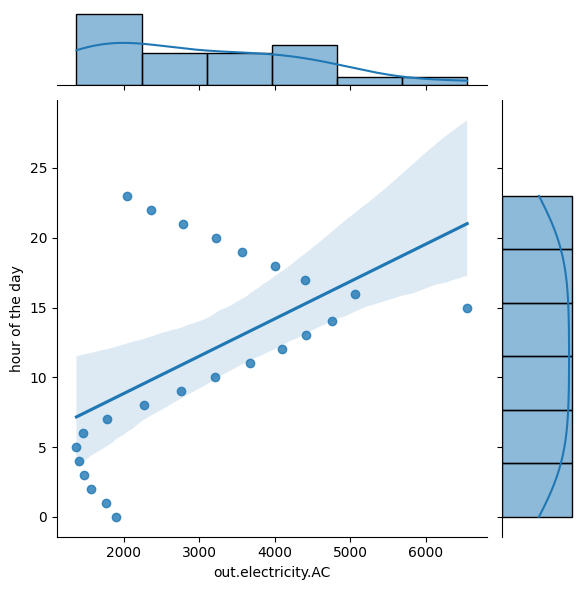

In [27]:
def display_totals(df):
    sns.jointplot(data=df, x='out.electricity.AC', y='hour of the day', kind='reg')
display_totals(long_duration)

## we Found that the ac correlates more to the values to the total consumption of energy

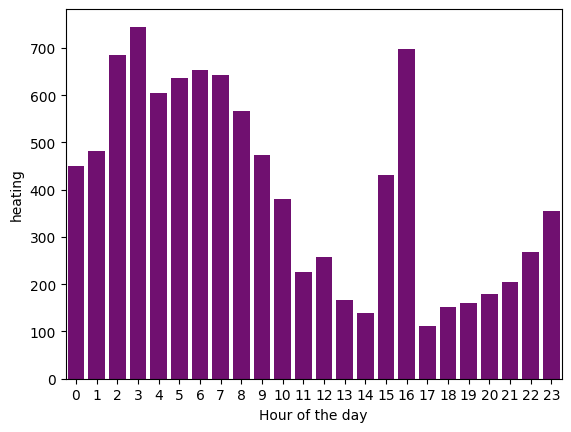

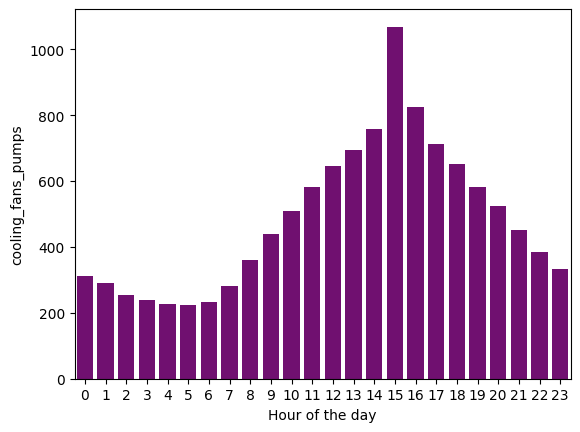

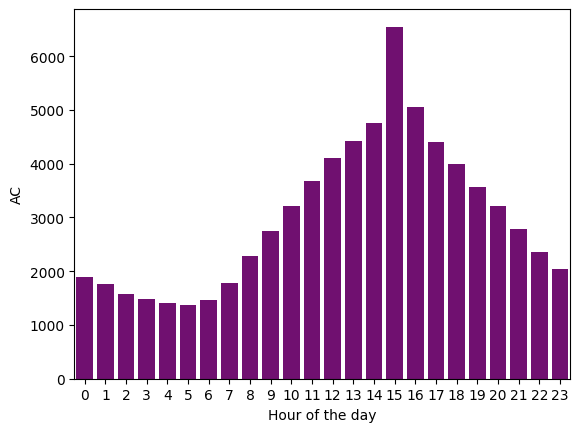

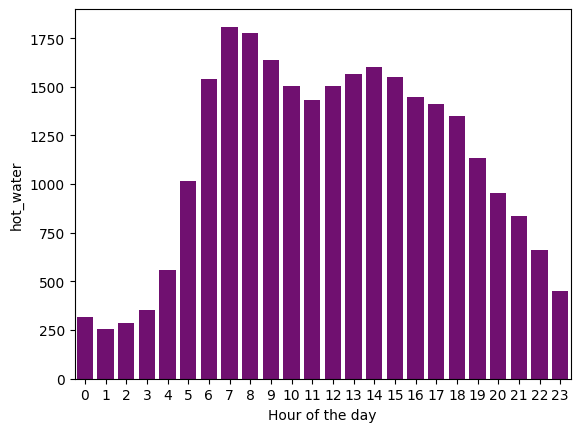

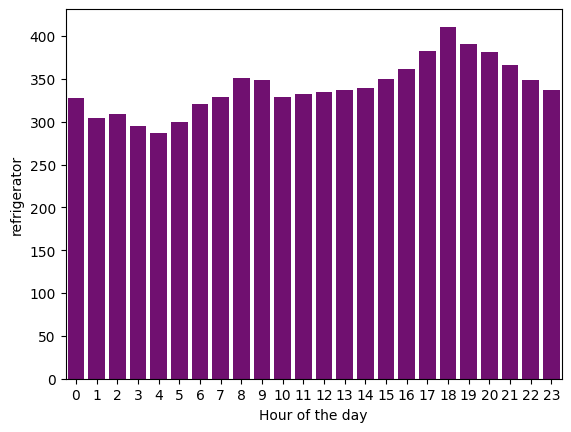

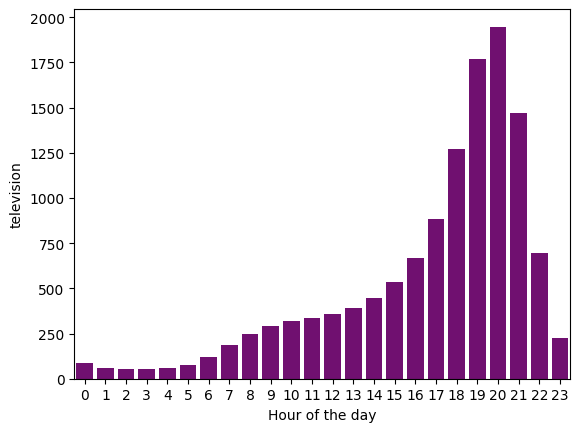

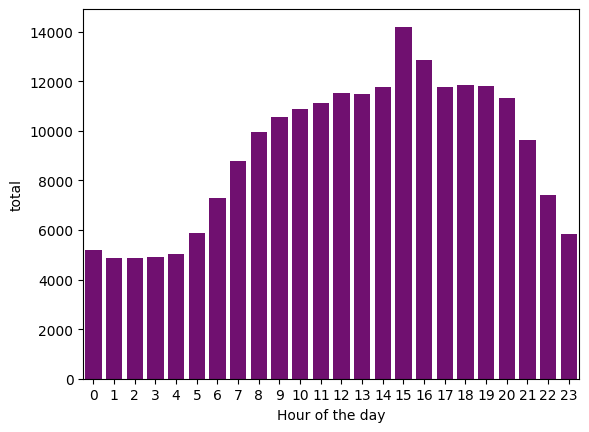

In [28]:
# visualizing long duration devices per each hour of the day by having a barplot
def long_dev_hourly(df):
    cols=[col for col in df.columns if col.startswith('out.electricity')]
    for col in cols:
        plot=sns.barplot(data=df, x='hour of the day', y=col, color='purple')
        label=col.removeprefix('out.electricity.')
        plot.set(xlabel='Hour of the day', ylabel=label)
        plt.show()
long_dev_hourly(long_duration)

In [32]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
def test_corr(df,var):
    cols=[col for col in df.columns if col.startswith('out.electricity') and col != var]
    arr=[]
    for col in cols:
        p_corr, p_val=stats.pearsonr(df[col], df[var])
        df_test=pd.DataFrame({
        "p_value":[p_val],
        "pearson correlation:" : [p_corr],
        "col": [col]})
        arr.append(df_test)
    return pd.concat(arr)
test_corr(long_duration, 'hour of the day')

,p_value,pearson correlation:,col
0,0.000242,-0.682004,out.electricity.heating
0,0.007029,0.535287,out.electricity.cooling_fans_pumps
0,0.007767,0.529692,out.electricity.AC
0,0.283195,0.228339,out.electricity.hot_water
0,0.000020,0.755192,out.electricity.refrigerator
0,0.000046,0.733320,out.electricity.television
0,0.002715,0.584319,out.electricity.total


## the p-value for the correlation between all appliances and total consumption with the hour of the

### Objective 2: the day of the month singificantly impact the consumption pattern

### Objective 3: the week of the month singificantly impact the consumption pattern

### Objective 4: the month of the year singificantly impact the consumption pattern

## Second Hypothesis

net total energy consumption determines the peak load periods

## Third Hypothesis

Simultaneous operation of two appliance creates a load on user's side

In [ ]:
##TODO: Make a pairplot for all long duration appliances generally
## TODO: Make a pairplot for all long duration appliances using correlations like is_Holiday
sns.pairplot(data=long_duration.to_pandas())

This proves hypothesis four that there is a relationship between devices

## Fourth Hypothesis

User Behaviour analysis